In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

CALCULATED MATRICS
R2_SCORE:  6.0623e-01
MSE:  5.2432e-01
MAE:  5.3116e-01
TRAINING SET METRICS
R² Score: 6.1255e-01
MSE: 5.1793e-01
MAE: 5.2863e-01
TEST SET METRICS
R² Score: 5.7579e-01
MSE: 5.5589e-01
MAE: 5.3320e-01


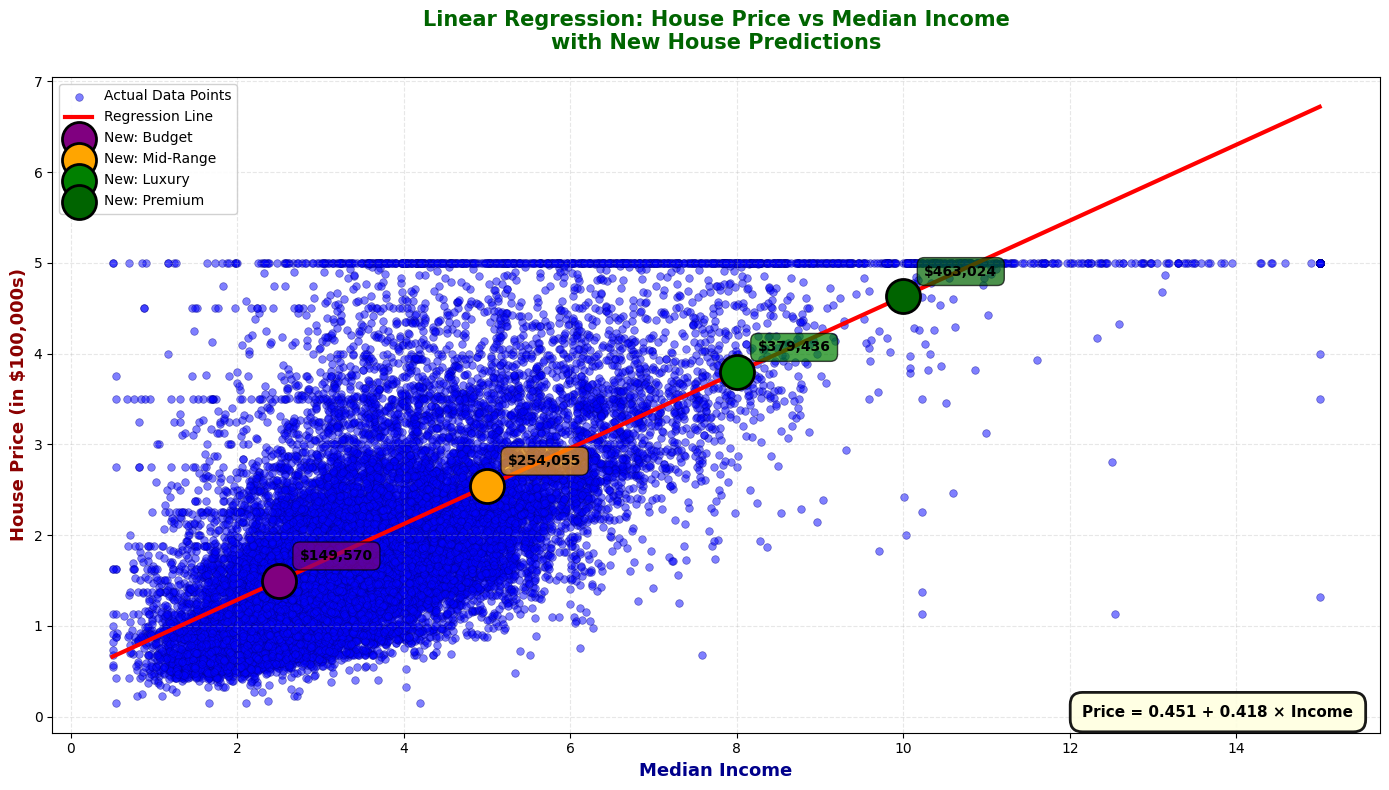

NEW HOUSE PREDICTIONS

Budget House:
  Income Level   : $2.50
  Predicted Price: $149,570.20

Mid-Range House:
  Income Level   : $5.00
  Predicted Price: $254,054.82

Luxury House:
  Income Level   : $8.00
  Predicted Price: $379,436.37

Premium House:
  Income Level   : $10.00
  Predicted Price: $463,024.07


In [ ]:
# LOAD AND PREPARE
housing=fetch_california_housing()
X=housing.data
y=housing.target

# TRAIN MODEL
model=LinearRegression()
model.fit(X,y)

# MAKE PREDICTION
y_pred=model.predict(X)

# CALCULATE MATRICS
r2=r2_score(y,y_pred)
mse=mean_squared_error(y,y_pred)
mae=mean_absolute_error(y,y_pred)

print("=" * 60)
print("CALCULATED MATRICS")
print("=" * 60)
print("R2_SCORE: ",f"{r2:.4e}")
print("MSE: ",f"{mse:.4e}")
print("MAE: ",f"{mae:.4e}")

# TRAIN AND TEST SPLIT
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# TRAIN MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# MAKE PREDICTIONS ON TRAIN DATA
y_pred_train = model.predict(X_train)
# MAKE PREDICTIONS ON TEST DATA
y_pred_test = model.predict(X_test)

# CALCULATE METRICS
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("=" * 60)
print("TRAINING SET METRICS")
print("=" * 60)
print(f"R² Score: {r2_train:.4e}")
print(f"MSE: {mse_train:.4e}")
print(f"MAE: {mae_train:.4e}")

print("=" * 60)
print("TEST SET METRICS")
print("=" * 60)
print(f"R² Score: {r2_test:.4e}")
print(f"MSE: {mse_test:.4e}")
print(f"MAE: {mae_test:.4e}")

# PLOT DATA POINT + REGRESSION LINE

# Use single feature for visualization
X_plot = housing.data[:, 0].reshape(-1, 1)
model_plot = LinearRegression()
model_plot.fit(X_plot, y)

# Regression line
X_range = np.linspace(X_plot.min(), X_plot.max(), 100).reshape(-1, 1)
y_line = model_plot.predict(X_range)

# New houses
new_houses = {
    "Budget":    [2.5],
    "Mid-Range": [5.0],
    "Luxury":    [8.0],
    "Premium":   [10.0],
}

predictions = {}
for house_type, income in new_houses.items():
    pred_price = model_plot.predict([income])[0]
    predictions[house_type] = {'income': income[0], 'price': pred_price}

# Plot
plt.figure(figsize=(14, 8))

plt.scatter(X_plot, y, alpha=0.5, color='blue', s=30,
           label='Actual Data Points', edgecolors='darkblue', linewidth=0.5)

plt.plot(X_range, y_line, color='red', linewidth=3,
        label='Regression Line')

colors_map = {
    'Budget': 'purple',
    'Mid-Range': 'orange',
    'Luxury': 'green',
    'Premium': 'darkgreen'
}

for house_type, pred_data in predictions.items():
    income = pred_data['income']
    price = pred_data['price']

    plt.scatter(income, price, s=600, marker='o',
               color=colors_map[house_type],
               edgecolors='black', linewidth=2,
               label=f'New: {house_type}', zorder=5)

    plt.annotate(f"${price*100000:,.0f}",
                xy=(income, price),
                xytext=(15, 15),
                textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5',
                         facecolor=colors_map[house_type],
                         alpha=0.7, edgecolor='black'),
                arrowprops=dict(arrowstyle='->',
                               connectionstyle='arc3,rad=0.3',
                               lw=1.5))

plt.xlabel('Median Income', fontsize=13,
          fontdict={'color': 'darkblue', 'fontweight': 'bold'})
plt.ylabel('House Price (in $100,000s)', fontsize=13,
          fontdict={'color': 'darkred', 'fontweight': 'bold'})
plt.title('Linear Regression: House Price vs Median Income\nwith New House Predictions',
         fontsize=15, fontweight='bold', color='darkgreen', pad=20)

plt.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')

equation = f'Price = {model_plot.intercept_:.3f} + {model_plot.coef_[0]:.3f} × Income'
plt.text(0.98, 0.02, equation,
        transform=plt.gca().transAxes,
        fontsize=11, ha='right', va='bottom', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow',
                 edgecolor='black', linewidth=2, alpha=0.9))

plt.tight_layout()
plt.show()

# =============================================
# PRINT NEW HOUSE PREDICTIONS
# =============================================
print("=" * 60)
print("NEW HOUSE PREDICTIONS")
print("=" * 60)
for house_type, pred_data in predictions.items():
    income = pred_data['income']
    price = pred_data['price']
    print(f"\n{house_type} House:")
    print(f"  Income Level   : ${income:.2f}")
    print(f"  Predicted Price: ${price*100000:,.2f}")
print("=" * 60)

